# 01 · EDA — estructura de datos y grafo de changeovers

Este notebook documenta la estructura de datos que se usa en el análisis estadístico y en el modelo de grafos.

Definición operativa:

- **Nodo** = `marca × volumen × pack × envase`.
- **Arista** = transición cronológica `prev_node → node` dentro de la misma línea y semana.
- **Tipo de arista** = primer atributo que cambia: `C_brand`, `C_vol`, `C_pack`, `C_envase`, o `C0_self`.
- **SKU** se conserva como atributo operativo para demanda y throughput, pero no es la identidad principal del grafo.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loaders import LINES, load_all_operations, add_graph_node_columns, classify_graph_edge
from post_mortem import PostMortemAnalyzer

DATA_DIR = Path('../raw_data')
CLEAN_DIR = Path('../clean_data')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


## 1 · Fuentes crudas y CSV limpios importantes

Los Excel crudos son la fuente de verdad. Los CSV de `clean_data/` son artefactos derivados para la app, optimizadores y visualizaciones.


In [2]:
ops = load_all_operations(DATA_DIR)

raw_catalog = pd.DataFrame([
    {'key':'oee', 'archivo':'OEE 14_17_19_ 2025.xlsx', 'uso':'OEE por OF, atributos de producto, línea y fecha'},
    {'key':'cam', 'archivo':'Cambios 14_17_19_ 2025.xlsx', 'uso':'duración del cambio, tipo principal y pack/material_precio'},
    {'key':'mant', 'archivo':'Mantenimiento 14_17_19_ 2025.xlsx', 'uso':'aislar OEE contaminado por mantenimiento'},
    {'key':'tiem', 'archivo':'Tiempo 14_17_19_ 2025.xlsx', 'uso':'horas totales por OF y throughput'},
    {'key':'vol', 'archivo':'Volumen 14_17_19_ 2025.xlsx', 'uso':'HL/UDS por OF y throughput'},
])
raw_catalog['filas'] = raw_catalog['key'].map({k: len(v) for k, v in ops.items()})
raw_catalog['columnas'] = raw_catalog['key'].map({k: len(v.columns) for k, v in ops.items()})
print(raw_catalog.to_string(index=False))

clean_files = ['historical_weeks.csv', 'changeovers.csv', 'frames_2025.csv', 'nodes_2025.csv',
               'throughput_rates.csv', 'demand.csv', 'historical_pairs.csv', 'sku_info.csv',
               'sku_eligibility.csv', 'black_spots_2025.csv']
rows = []
for name in clean_files:
    path = CLEAN_DIR / name
    if path.exists():
        df = pd.read_csv(path)
        rows.append({'csv': name, 'filas': len(df), 'columnas': len(df.columns), 'columnas_clave': ', '.join(df.columns[:8])})
    else:
        rows.append({'csv': name, 'filas': 'no existe', 'columnas': '—', 'columnas_clave': '—'})
clean_catalog = pd.DataFrame(rows)
print('\nCSV derivados relevantes:')
print(clean_catalog.to_string(index=False))


 key                           archivo                                                        uso  filas  columnas
 oee           OEE 14_17_19_ 2025.xlsx           OEE por OF, atributos de producto, línea y fecha   2141        43
 cam       Cambios 14_17_19_ 2025.xlsx duración del cambio, tipo principal y pack/material_precio   2181        22
mant Mantenimiento 14_17_19_ 2025.xlsx                   aislar OEE contaminado por mantenimiento   2142        23
tiem        Tiempo 14_17_19_ 2025.xlsx                          horas totales por OF y throughput   2143        33
 vol       Volumen 14_17_19_ 2025.xlsx                                 HL/UDS por OF y throughput   2143        19

CSV derivados relevantes:
                 csv  filas  columnas                                                            columnas_clave
historical_weeks.csv   2141        18         of, fecha, line, sku, marca, envase, tipo_envase, material_precio
     changeovers.csv    978         8   line, prev_node, ne

## 2 · Limpieza mínima y construcción del nodo

La limpieza compartida hace tres cosas relevantes para este proyecto:

1. Normaliza nombres de columnas y líneas (`14`, `17`, `19`).
2. Excluye registros no-productivos como `LIMPIEZA`.
3. Construye `node = marca|volumen|pack|envase` usando `marca`, `tipo_envase`, `material_precio` y `envase`.


In [3]:
df_cam_nodes = add_graph_node_columns(ops['cam'])
cols = ['of', 'fecha', 'sku', 'marca', 'tipo_envase', 'material_precio', 'envase',
        'node_marca', 'node_volumen', 'node_pack', 'node_envase', 'node',
        'freq_total', 'c_principal']
print(df_cam_nodes[[c for c in cols if c in df_cam_nodes.columns]].head(10).to_string(index=False))

quality_rows = []
for name, df in ops.items():
    for col in ['of', 'fecha', 'sku', 'tren', 'marca', 'tipo_envase', 'material_precio', 'envase']:
        if col in df.columns:
            quality_rows.append({'tabla': name, 'columna': col, 'missing_pct': 100*df[col].isna().mean(), 'n_unique': df[col].nunique(dropna=True)})
quality = pd.DataFrame(quality_rows)
print('\nCalidad de columnas usadas:')
print(quality.pivot(index='columna', columns='tabla', values='missing_pct').round(1).fillna('—').to_string())


          of      fecha      sku           marca  tipo_envase                    material_precio  envase      node_marca node_volumen node_pack node_envase                            node  freq_total      c_principal
0000519446-1 2025-01-07  ED12LTW   ESTRELLA DAMM LATA 1/2 SR.             ESTRELLA DAMM 1/2 LATA KR00127   ESTRELLA DAMM          1/2       UNI     KR00127   ESTRELLA DAMM|1/2|UNI|KR00127         NaN   Volumen Envase
0000519449-1 2025-01-09  VI13L6N        VICTORIA LATA 1/3 SR. VICTORIA 1/3 LATA PACK CERRADO 6U. KR81115        VICTORIA          1/3        P6     KR81115         VICTORIA|1/3|P6|KR81115    1.093889   Pack, Primario
0000519450-1 2025-01-02 VI13LP6M        VICTORIA LATA 1/3 SR. VICTORIA 1/3 LATA PACK CERRADO 6U. KR81115        VICTORIA          1/3        P6     KR81115         VICTORIA|1/3|P6|KR81115         NaN   Pack, Primario
0000519460-1 2025-01-11   CM13LT         COMPLOT LATA 1/3 SR.                COMPLOT 1/3 LATA LC KR05002         COMPLOT          1/

## 3 · Dataset analítico: secuencias y aristas

El dataset que alimenta `postmortem_analysis` y `statistical_analysis` reconstruye la secuencia semanal por línea. La primera OF de cada semana no genera arista; el resto sí.


In [4]:
analyzer = PostMortemAnalyzer(
    df_oee=ops['oee'], df_cambios=ops['cam'], df_mantenimiento=ops['mant'],
    df_tiempo=ops['tiem'], df_volumen=ops['vol'],
)
df_clean = analyzer.clean_and_isolate_maintenance()
seq = analyzer.get_sequences()
transitions = seq[~seq['es_primera_of_semana']].copy()

structure_cols = ['fecha', 'tren', 'sku_prev', 'sku', 'prev_node', 'node', 'edge_type',
                  'freq_total', 'oee_seq', 'mant_ratio', 'hl', 'h_tot_of']
print('Estructura del dataset de aristas:')
print(transitions[[c for c in structure_cols if c in transitions.columns]].head(12).to_string(index=False))

summary = pd.DataFrame({
    'métrica': ['OF limpias', 'transiciones', 'nodos únicos', 'aristas únicas', 'SKUs únicos'],
    'valor': [len(df_clean), len(transitions), seq['node'].nunique(), transitions.groupby(['tren','prev_node','node']).ngroups, seq['sku'].nunique()]
})
print('\nResumen:')
print(summary.to_string(index=False))


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
Estructura del dataset de aristas:
     fecha tren sku_prev      sku                     prev_node                          node edge_type  freq_total  oee_seq  mant_ratio      hl  h_tot_of
2025-01-04   14 VI13LP6M VO13LTNN       VICTORIA|1/3|P6|KR81115     VOLL DAMM|1/3|UNI|KR00525   C_brand         NaN 0.317267    0.000000  734.63 11.693611
2025-01-03   14 VO13LTNN  VI13L6N     VOLL DAMM|1/3|UNI|KR00525       VICTORIA|1/3|P6|KR81115   C_brand    5.962500 0.412940    1.039413  276.78 11.925000
2025-01-09   14  ED12LTW  VI13L6N ESTRELLA DAMM|1/2|UNI|KR00127       VICTORIA|1/3|P6|KR81115   C_brand    1.093889 0.370797    0.000000  401.60  5.469444
2025-01-09   14  VI13L6N ED13LCMM       VICTORIA|1/3|P6|KR81115 ESTRELLA DAMM|1/3|UNI|KR00440   C_brand    2.640069 0.416225    1.009706  278.81 10.560278
2025-01-10   14 ED13LCMM VI13LP6M ESTRELLA DAMM|1/3|UNI|KR00440     

## 4 · EDA del grafo de cambio

Miramos cobertura por línea, composición de tipos de arista y distribución de duración de cambio.


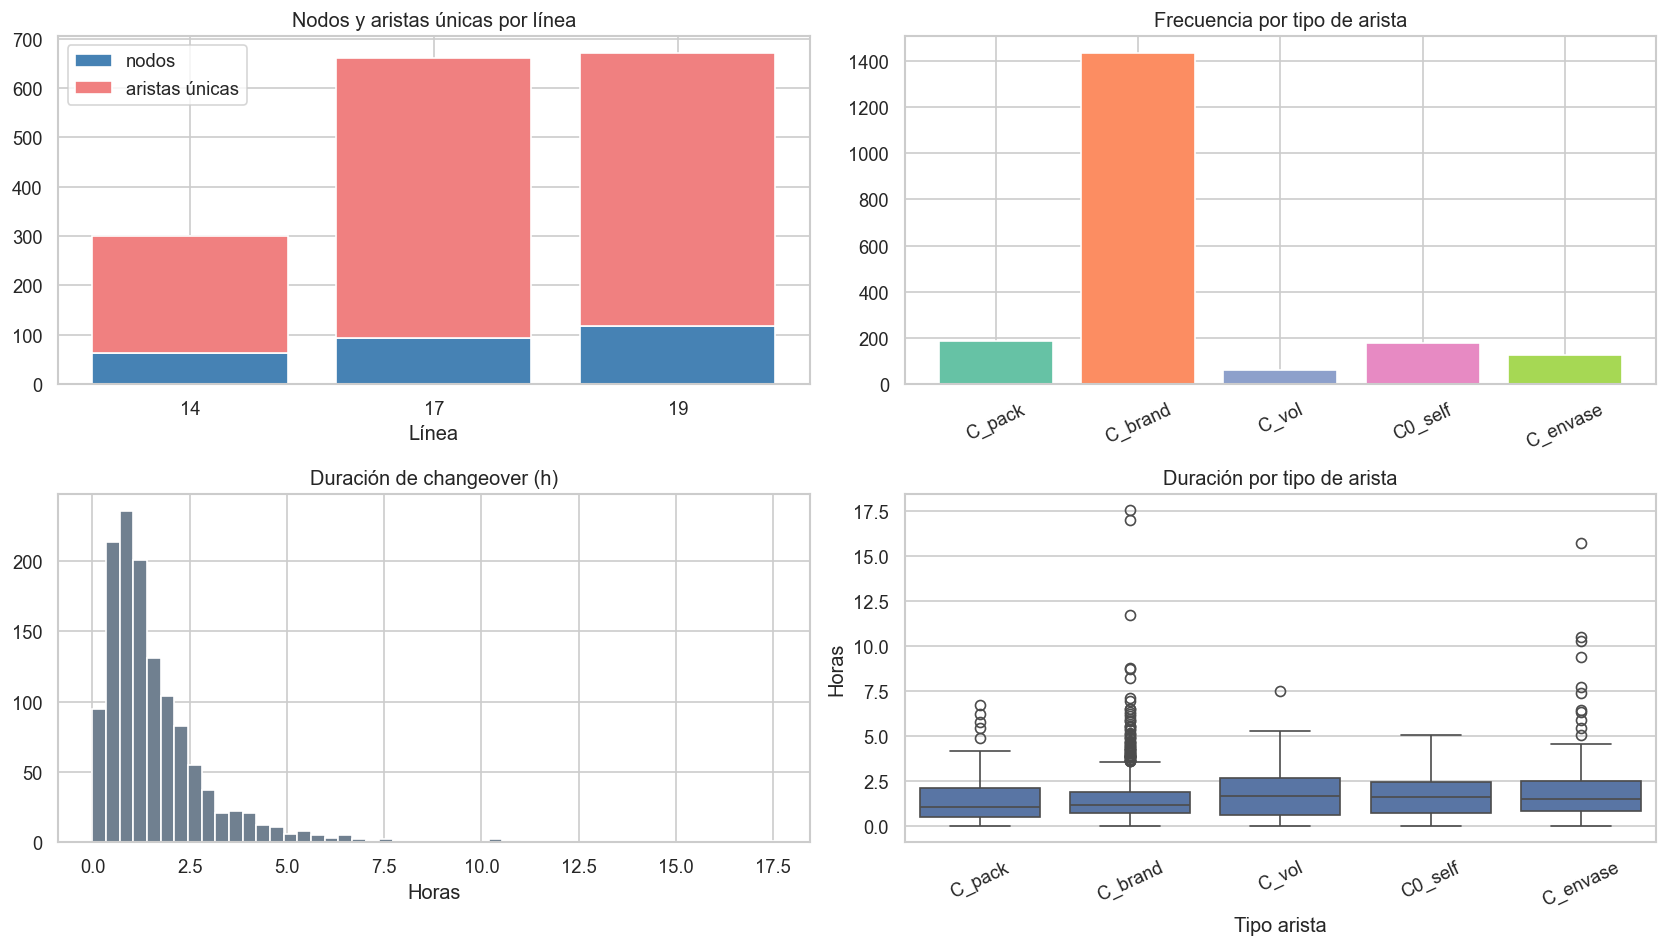

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

node_line = seq.groupby('tren')['node'].nunique().reindex(LINES)
edge_line = transitions.groupby('tren').apply(lambda x: x.groupby(['prev_node','node']).ngroups).reindex(LINES)
axes[0,0].bar(node_line.index, node_line.values, color='steelblue', label='nodos')
axes[0,0].bar(edge_line.index, edge_line.values, bottom=node_line.values, color='lightcoral', label='aristas únicas')
axes[0,0].set_title('Nodos y aristas únicas por línea')
axes[0,0].set_xlabel('Línea'); axes[0,0].legend()

edge_counts = transitions['edge_type'].value_counts().reindex(['C_pack','C_brand','C_vol','C0_self','C_envase']).dropna()
axes[0,1].bar(edge_counts.index, edge_counts.values, color=sns.color_palette('Set2', len(edge_counts)))
axes[0,1].set_title('Frecuencia por tipo de arista')
axes[0,1].tick_params(axis='x', rotation=25)

hours = transitions['freq_total'].dropna()
hours = hours.where(hours <= 30, hours/60.0)
axes[1,0].hist(hours, bins=50, color='slategray', edgecolor='white')
axes[1,0].set_title('Duración de changeover (h)')
axes[1,0].set_xlabel('Horas')

plot_df = transitions[['edge_type','freq_total']].dropna().copy()
plot_df['hours'] = np.where(plot_df['freq_total'] > 30, plot_df['freq_total']/60.0, plot_df['freq_total'])
order = ['C_pack','C_brand','C_vol','C0_self','C_envase']
sns.boxplot(data=plot_df, x='edge_type', y='hours', order=[o for o in order if o in plot_df['edge_type'].unique()], ax=axes[1,1])
axes[1,1].set_title('Duración por tipo de arista')
axes[1,1].set_xlabel('Tipo arista'); axes[1,1].set_ylabel('Horas')
axes[1,1].tick_params(axis='x', rotation=25)

plt.tight_layout(); plt.show()


## 5 · Qué se usa y qué no

**Se usa directamente:**

- `of`, `fecha`, `tren`, `sku` para ordenar y trazar cada OF.
- `marca`, `tipo_envase`, `material_precio`, `envase` para construir el nodo.
- `freq_total` como duración de changeover.
- `oee`, `h_tot`, `hl`, mantenimiento para post-mortem y throughput.

**No se usa como identidad del grafo:**

- `sku` por sí solo. El SKU puede ser útil para demanda, pero el grafo representa estados de producto/formato.
- `c_principal` como clasificación final. Lo conservamos como referencia industrial, pero `edge_type` se deriva de los atributos del nodo para ser consistente con el análisis estadístico.
